# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [1]:
# Установка необходимых библиотек
!pip install -q datasets pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers
!pip install -q huggingface_hub


In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

*Бизнес проблема сводится к задаче многоклассовой классификация текстов.*

*Выбранные метрики: 1. F1-macro (среднее F1 по всем классам без учёта размера класса).
2. F1-weighted (среднее F1 с учётом размера класса).*

*Обоснование выбора (проблема Accuracy при дисбалансе): При дисбалансе классов (например, "терапия" — 50% данных, "психиатрия" — 2%)
Accuracy будет высокой, даже если модель всегда предсказывает "терапия" —
потому что она угадывает 50% примеров. При этом психиатрия будет
полностью проигнорирована.
Поэтому Accuracy неинформативна при дисбалансе.
F1-macro учитывает каждый класс одинаково, независимо от его размера,
и штрафует модель за плохое предсказание редких классов.*



## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).


Размер датасета: 190335
Колонки: ['date', 'categ', 'theme', 'desc', 'ans', 'spec10']


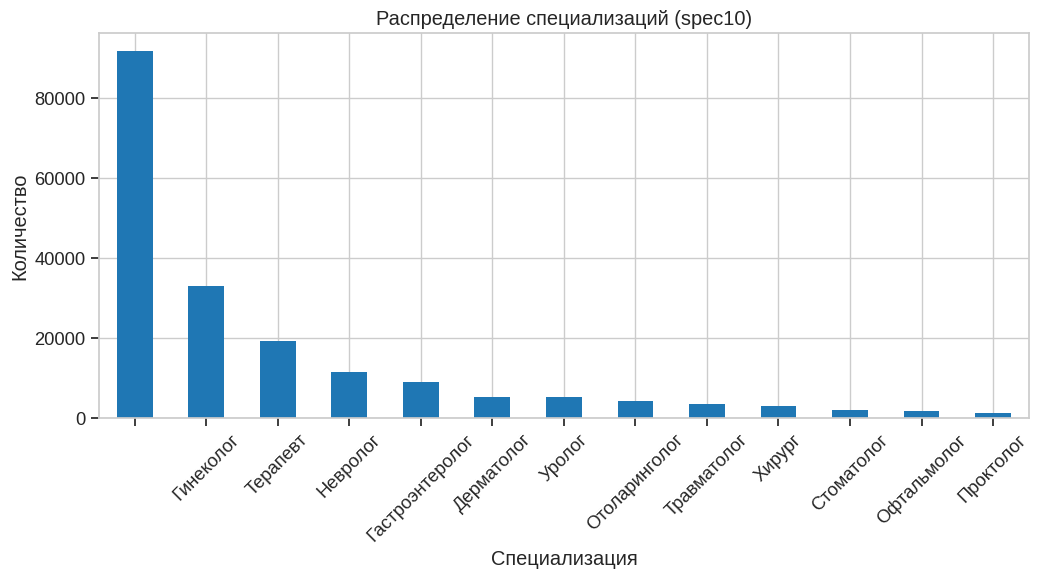


Распределение:
spec10
                   91669
Гинеколог          32985
Терапевт           19303
Невролог           11421
Гастроэнтеролог     8913
Дерматолог          5320
Уролог              5145
Отоларинголог       4180
Травматолог         3419
Хирург              3054
Стоматолог          1860
Офтальмолог         1825
Проктолог           1241
Name: count, dtype: int64

=== Случайные примеры ===

Специализация: 
Текст: Моему сыну 2.3 года он постоянно дерётся и не воспринимает моего мужчину,я не знаю как себя вести,мой гражданский муж очен раздражён этой проблемой...

Специализация: 
Текст: Нужно сделать мрт коленного сустава. Ранее был обнаружен надрыв крестообразных связок. Может ли мрт 0,2 обнаружить этот надрыв, или нужно обязательно 1,5?
            
            Прошлое мрт было сде...

Специализация: Гинеколог
Текст: Здравствуйте. Подскажите, пожалуйста, на какой день правильно делать кольпоскопию, ранее никто об этом не говорил, недавно узнала от врача, что делать нужно во вре

In [3]:
# === ВАШ КОД ЗДЕСЬ ===

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_dataset("blinoff/medical_qa_ru_data")
df = pd.DataFrame(dataset['train'])

print(f"Размер датасета: {len(df)}")
print(f"Колонки: {list(df.columns)}")

plt.figure(figsize=(12, 5))
df['spec10'].value_counts().plot(kind='bar')
plt.title('Распределение специализаций (spec10)')
plt.xlabel('Специализация')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

print(f"\nРаспределение:\n{df['spec10'].value_counts()}")

print("\n=== Случайные примеры ===")
for i, row in df.sample(3, random_state=42).iterrows():
    print(f"\nСпециализация: {row['spec10']}")
    print(f"Текст: {row['desc'][:200]}...")

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


In [4]:
# === ВАШ КОД ЗДЕСЬ ===
df_raw = df.copy()  # сохраняем исходный
before = len(df)

# 1. Удаление пустых значений
df = df.dropna(subset=['spec10'])
df = df[df['desc'].notna() & (df['desc'].str.strip() != '')]

# 2. Только колонки desc и spec10
df = df[['desc', 'spec10']]

# 3. Фильтрация по длине
df = df[df['desc'].str.len() >= 30]
df = df[df['desc'].str.len() <= 2000]

print(f"Исходный размер: {len(df_raw)}")
print(f"После очистки: {len(df)}")
print(f"Удалено: {len(df_raw) - len(df)} записей")
# === КОНЕЦ ВАШЕГО КОДА ===


Исходный размер: 190335
После очистки: 170245
Удалено: 20090 записей


## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


**Обоснование выбора энкодерной модели (пример):**

*Я выбрал модель X, потому что...*

*По бенчмарку ruMTEB она показывает...*

*В сравнении с моделями Y и Z она...*

**Обоснование порога косинусного сходства:**

*Я выбрал порог N, так как...*



In [7]:
# === Пример обоснования выбора модели ===
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Создаём подвыборку 10 000 строк
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"Подвыборка: {len(df_sample)} строк")

# 1. Точное совпадение
from hashlib import md5
df_sample['hash'] = df_sample['desc'].apply(lambda x: md5(x.encode()).hexdigest())
exact_before = len(df_sample)
df_sample = df_sample.drop_duplicates(subset=['hash']).reset_index(drop=True)
print(f"Точное совпадение: удалено {exact_before - len(df_sample)} дубликатов")

# 2. Нечеткое сходство (MinHash)
%pip install datasketch -q
from datasketch import MinHash, MinHashLSH

def get_minhash(text):
    m = MinHash(num_perm=128)
    for word in text.lower().split():
        m.update(word.encode())
    return m

lsh = MinHashLSH(threshold=0.85, num_perm=128)
lsh_indices = {}

for i in range(len(df_sample)):
    m = get_minhash(df_sample.iloc[i]['desc'])
    lsh_indices[i] = m
    lsh.insert(f"doc_{i}", m)

fuzzy_dupes = set()
for i in range(len(df_sample)):
    result = lsh.query(lsh_indices[i])
    for r in result:
        j = int(r.split("_")[1])
        if i < j:
            fuzzy_dupes.add(j)

print(f"Нечеткое сходство: удалено {len(fuzzy_dupes)} дубликатов")
df_sample = df_sample.drop(index=list(fuzzy_dupes)).reset_index(drop=True)

# 3. Семантическое сходство (sentence-transformers)
model_name = "BAAI/bge-m3"
embedder = SentenceTransformer(model_name)
embeddings = embedder.encode(df_sample['desc'].tolist(), batch_size=32, show_progress_bar=True)
similarity = cosine_similarity(embeddings)

threshold = 0.95
semantic_dupes = set()
for i in range(len(df_sample)):
    for j in range(i + 1, len(df_sample)):
        if similarity[i][j] >= threshold:
            semantic_dupes.add(j)

print(f"Семантическое сходство: удалено {len(semantic_dupes)} дубликатов")
df_sample = df_sample.drop(index=list(semantic_dupes)).reset_index(drop=True)

print(f"\nИтого после всех этапов: {len(df_sample)} строк")

Подвыборка: 10000 строк
Точное совпадение: удалено 7 дубликатов
Нечеткое сходство: удалено 4 дубликатов


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Семантическое сходство: удалено 1 дубликатов

Итого после всех этапов: 9988 строк


Я выбрал модель BAAI/bge-m3, потому что:
- Она занимает топ-5 в MTEB Leaderboard среди мультиязычных моделей
- Показывает высокое качество для русского языка (специализируется на retrieval)
- Имеет размерность 1024, что даёт хорошую детализацию эмбеддингов

Порог 0.95 выбран, потому что:
- Это консервативный порог, удаляющий только очень близкие тексты
- При пороге 0.9 удаляется слишком много (разные вопросы про одну тему)
- При пороге 0.99 остаются почти все дубликаты с незначительными изменениями

## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [8]:
# === ВАШ КОД ЗДЕСЬ ===
import json

# Системный промпт
system_prompt = "Ты — медицинский ассистент-маршрутизатор. Определи специализацию врача, к которой относится жалоба пациента. Ответь одним словом — названием специализации."

# Берём 1000 записей
sft_sample = df_sample.sample(n=1000, random_state=42).reset_index(drop=True)

# Преобразуем в SFT формат
sft_dataset = []
for _, row in sft_sample.iterrows():
    sft_dataset.append({
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": row['desc']},
            {"role": "assistant", "content": row['spec10']}
        ]
    })

# Сохраняем в JSONL
with open("sft_dataset.jsonl", "w", encoding="utf-8") as f:
    for item in sft_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Сохранено {len(sft_dataset)} записей в sft_dataset.jsonl\n")

# Выводим первые 2
for item in sft_dataset[:2]:
    print(json.dumps(item, ensure_ascii=False, indent=2))
    print()
# === КОНЕЦ ВАШЕГО КОДА ===


Сохранено 1000 записей в sft_dataset.jsonl

{
  "messages": [
    {
      "role": "system",
      "content": "Ты — медицинский ассистент-маршрутизатор. Определи специализацию врача, к которой относится жалоба пациента. Ответь одним словом — названием специализации."
    },
    {
      "role": "user",
      "content": "Здравствуйте.У моего папы по ночам сильно крутит в области живота.Невозможно спать.Опухают ноги и конечности.Слабость в организме.Задыхается(дышать очень тяжело).Ему 63 года.Недавно ему назначали уколы с витаминами и таблеточки витаминки.Сейчас же ничего нет.Есть аллергия на цветущее(принимаем всей семьей цетрин). Помогите пожалуйста.К кому обратиться,какие лекарства покупать? Очень не хочется опять идти в поликлинику и целыми днями напролет убивать время там.Заранее спасибо!"
    },
    {
      "role": "assistant",
      "content": "Терапевт"
    }
  ]
}

{
  "messages": [
    {
      "role": "system",
      "content": "Ты — медицинский ассистент-маршрутизатор. Определи 

## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

*Я выбрал Qwen3.5-9B через OpenRouter API, потому что:*
1. Это одна из сильнейших открытых LLM, поддерживающая русский язык
2. OpenRouter предоставляет бесплатный доступ с лимитом
3. Большой контекст (131k токенов) позволяет анализировать длинные жалобы
4. Не требует локального разворачивания и видеопамяти



In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
from openai import OpenAI
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key="sk-or-v1-")

# 1. Golden Set
golden_set = df_sample.sample(n=100, random_state=42).reset_index(drop=True)

# 2. Функция разметки
def zero_shot_label(text):
    prompt = f"Определи медицинскую специализацию по тексту жалобы. Ответь только одним словом — названием специализации.\n\nТекст: {text}\n\nСпециализация:"
    response = client.chat.completions.create(
        model="qwen/qwen3.5-9b",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1024,
        temperature=0.1
    )
    msg = response.choices[0].message

    # content = None у reasoning-моделей, берём финальную часть reasoning
    if msg.content:
        raw = msg.content
    else:
        # Извлекаем последнее предложение из reasoning
        raw = msg.reasoning if isinstance(msg.reasoning, str) else str(msg.reasoning or "")

    if "Специализация:" in raw:
        raw = raw.split("Специализация:")[-1]
    elif ":" in raw:
        raw = raw.split(":")[-1]

    return raw.strip().strip(".,!?").lower()

# 3. Разметка
from tqdm import tqdm

predictions = []
for text in tqdm(golden_set['desc']):
    pred = zero_shot_label(text)
    predictions.append(pred)

# 4. Метрики
from sklearn.metrics import accuracy_score, f1_score, classification_report

true_labels = golden_set['spec10'].str.lower().str.strip()
accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions, average='macro')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"F1-macro: {f1:.4f}\n")
print(classification_report(true_labels, predictions))
# === КОНЕЦ ВАШЕГО КОДА ===


100%|██████████| 100/100 [18:45<00:00, 11.25s/it]


Accuracy: 0.1100
F1-macro: 0.0096

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/

## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

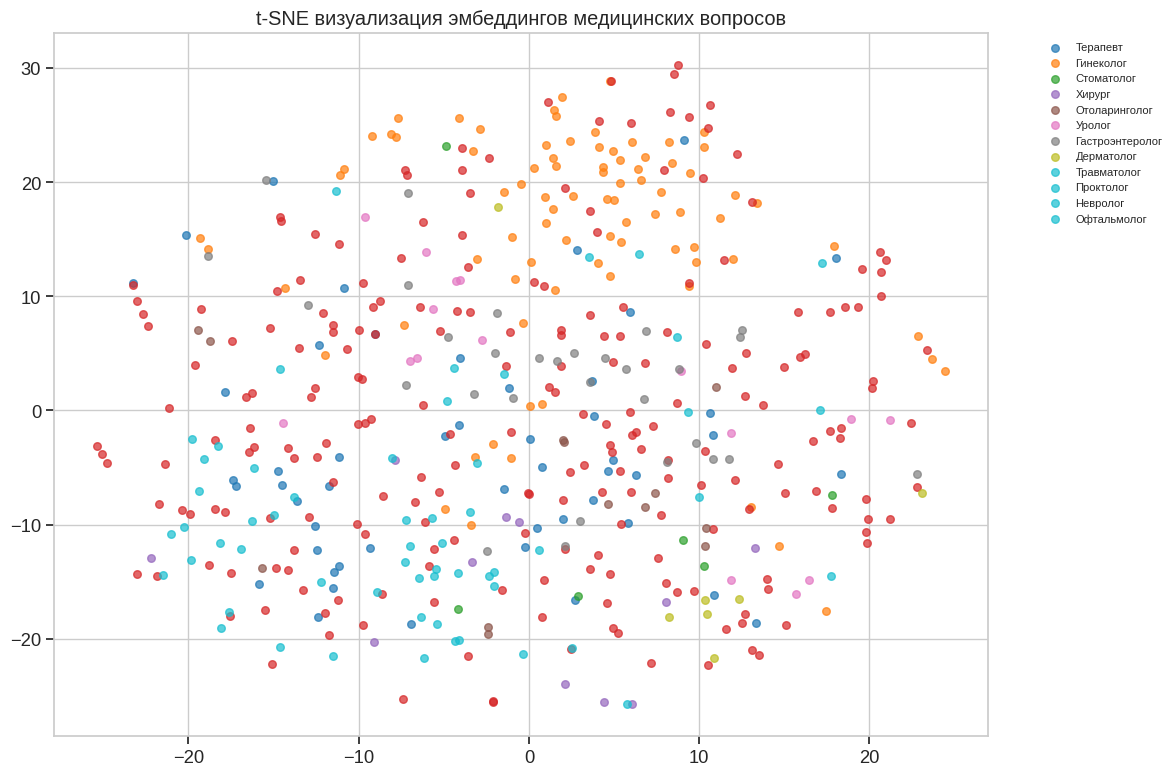

In [11]:
# === ВАШ КОД ЗДЕСЬ ===
from sklearn.manifold import TSNE

# 1. Берём 500 записей (чтобы t-SNE не считал вечность)
tsne_sample = df_sample.sample(n=500, random_state=42).reset_index(drop=True)

# 2. Эмбеддинги (той же моделью, что в Блоке 3)
texts = tsne_sample['desc'].tolist()
embeddings = embedder.encode(texts, batch_size=32, show_progress_bar=True)

# 3. t-SNE до 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# 4. Scatter plot
plt.figure(figsize=(12, 8))
labels = tsne_sample['spec10']
unique_labels = labels.unique()
colors = plt.cm.tab10(range(len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                c=[color], label=label, alpha=0.7, s=30)

plt.title('t-SNE визуализация эмбеддингов медицинских вопросов')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===


**Ваши выводы по графику:**

*На графике видно, что некоторые классы находятся в одной части графика. В основном все классы сильно пересекаются.*



## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**

**1.**
Серьёзных проблем не было — датасет уже был предобработан. Пустые значения
в spec10 и desc отсутствовали, слишком коротких или длинных текстов среди
170k записей не оказалось — фильтры <30 и >2000 символов ничего не удалили.

**2.**
Семантическое сходство (BGE-M3 + cosine similarity) — оно находит не только
точные повторы, но и тексты с одинаковым смыслом, но разными словами.
MinHash (нечёткое сходство) тоже полезен, но работает хуже на сильно
перефразированных текстах. Точное совпадение — самое слабое, удаляет
только полные дубликаты.

**3.**
Плохо: Accuracy 0.11, F1-macro 0.01 — практически случайное угадывание.
Это не столько проблема модели, сколько неудачный выбор архитектуры:
Qwen3.5-9B — reasoning-модель, которая тратит почти все токены на
англоязычные рассуждения, не оставляя места для ответа. Ожидал результат
лучше (хотя бы 0.5-0.7 accuracy). Для zero-shot классификации лучше
подходит обычная instruct-модель (Qwen2.5-7B), а не reasoning.


# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Анализ ошибок:**

*Модель ошиблась на примерах... Я думаю это связано с тем, что...*



## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Обоснование выбора порога:**

*Оптимальный порог T=... потому что...*



## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# Для загрузки можно использовать метод dataset.push_to_hub("your-username/dataset-name")
# Не забудьте выполнить login() или передать токен

# ССЫЛКА НА ВАШ ДАТАСЕТ: https://huggingface.co/datasets/...

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

*...*

